# Imports

In [ ]:
# biopython
import Bio
from Bio.Align import PairwiseAligner, substitution_matrices
# Parse PDB files
from Bio.PDB.MMCIFParser import MMCIFParser
from Bio.PDB import PPBuilder

# download pdb mmcif files
import requests

# Linear algebra
import numpy as np

# Dataframes
import pandas as pd

# Path and file handling
import os
data_path = os.path.join('..', 'data')

# Progress bar
from tqdm import tqdm

# Fast applying of functions to dataframes
import swifter

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Threading and I/O
from concurrent.futures import ThreadPoolExecutor, as_completed
from io import StringIO

C:\Users\wsega\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Data

In [3]:
test_with_results = pd.read_pickle(os.path.join(data_path, '2_test_with_bart30.pkl'))

ensembl_to_uniprot = pd.read_pickle('ensembl_to_uniprot.pkl')
id_mapping = pd.read_csv('idmapping_2025_04_02.tsv', sep='\t')

In [4]:
temp_data = pd.read_csv(os.path.join(data_path, 'genes_human.csv'), delimiter='\t')[['transcript', 'canonical', 'coord_start', 'coord_end', 'exp_T', 'exp_HEK293', 'exp_U2OS', 'cARS_T', 'cARS_HEK293', 'cARS_U2OS']]

merged_data = pd.merge(test_with_results, temp_data, right_on='transcript', left_on='query_transcript', how='left').drop(columns=['transcript'])

test_with_results = merged_data

# Match PDB IDs with ENSEMBL Gene IDs

In [ ]:
id_mapping = id_mapping.merge(ensembl_to_uniprot, left_on='From', right_on='uniprot_id', how='left')
id_mapping = id_mapping.drop(columns=['uniprot_id'])

transcripts = test_with_results[['query_gene', 'query_transcript', 'amino_acid_seq']]
id_mapping = id_mapping.merge(transcripts, left_on='ensembl_gene_id', right_on='query_gene', how='left')
id_mapping = id_mapping.drop(columns=['query_gene'])
id_mapping = id_mapping.rename(columns={'From': 'uniprot_id', 'To': 'pdb_id', 'amino_acid_seq': 'ensembl_amino_acid_seq', 'query_transcript': 'ensembl_transcript_id'})

In [ ]:
id_mapping

,uniprot_id,pdb_id,ensembl_gene_id,ensembl_transcript_id,ensembl_amino_acid_seq
0,P13569,1XMI,ENSG00000001626,ENST00000699599,MQRSPLEKASVVSKLFFSWTRPILRKGYRQRLELSDIYQIPSVDSA...
1,P13569,1XMI,ENSG00000001626,ENST00000699605,MFYGIFLYLGEVTKAVQPLLLGRIIASYDPDNKEERSIAIYLGIGL...
2,P13569,1XMI,ENSG00000001626,ENST00000699600,MQRSPLEKASVVSKLFFSWTRPILRKGYRQRLELSDIYQIPSVDSA...
3,P13569,1XMI,ENSG00000001626,ENST00000647978,MQRSPLEKASVVSKLFFSWTRPILRKGYRQRLELSDIYQIPSVDSA...
4,P13569,1XMI,ENSG00000001626,ENST00000699585,MQRSPLEKASVVSKLFFSWTRPILRKGYRQRLELSDIYQIPSVDSA...
...,...,...,...,...,...
148605,Q15428,8RM5,ENSG00000104897,ENST00000221494,MDFQHRPGGKTGSGGVASSSESNRDRRERLRQLALETIDINKDPYF...
148606,Q96GY3,7N40,ENSG00000267796,ENST00000301159,MFPVKVKVEKSELEMAKARNQLDAVLQCLLEKSHMDRERLDEEAGK...
148607,Q96GY3,7N40,ENSG00000267796,ENST00000595455,MFPVKVKVEKSELEMAKARNQLDAVLQCLLEKSHMDRERLDEEAGK...
148608,Q96GY3,7R1D,ENSG00000267796,ENST00000301159,MFPVKVKVEKSELEMAKARNQLDAVLQCLLEKSHMDRERLDEEAGK...


# Extract PDB Sequences

In [ ]:
# Extract PDB Sequences

df = id_mapping[['pdb_id', 'uniprot_id']].drop_duplicates()

results = []
os.makedirs("pdb_tmp", exist_ok=True)

def get_chains_from_sifts(pdb_id, uniprot_id):
    """Query PDBe SIFTS API to get chain(s) in PDB corresponding to a UniProt ID"""
    url = f"https://www.ebi.ac.uk/pdbe/api/mappings/uniprot/{pdb_id.lower()}"
    r = requests.get(url)
    if r.status_code != 200:
        return []
    
    data = r.json()
    chains = []
    
    mappings = data.get(pdb_id.lower(), {}).get('UniProt', {}).get(uniprot_id, {}).get("mappings", [])
    for m in mappings:
        chain_id = m.get("chain_id")
        if chain_id:
            chains.append(chain_id)
    
    return list(set(chains))  # Remove duplicates just in case

def process_pdb_entry(pdb_id, uniprot_id):
    parser = MMCIFParser(QUIET=True)  # separate instance for each thread to avoid errors
    ppb = PPBuilder()

    pdb_id_lower = pdb_id.lower()
    url = f"https://files.rcsb.org/download/{pdb_id_lower}.cif"

    try:
        r = requests.get(url, timeout=10)
        if r.status_code != 200:
            print(f"Failed to download {pdb_id}")
            return None

        # Use in-memory string buffer instead of writing to disk
        handle = StringIO(r.text)
        structure = parser.get_structure(pdb_id, handle)
        model = structure[0]

        chain_ids = get_chains_from_sifts(pdb_id, uniprot_id)
        if not chain_ids:
            print(f"No matching chain found in {pdb_id} for UniProt {uniprot_id}")
            return None

        local_results = []

        for chain in model.get_chains():
            if chain.id not in chain_ids:
                continue

            seq = ''.join(str(pp.get_sequence()) for pp in ppb.build_peptides(chain))
            mmcif_dict = parser._mmcif_dict
            ss_map = {}

            helices = mmcif_dict.get('_struct_conf.beg_auth_asym_id', [])
            for i, asym_id in enumerate(helices):
                if asym_id == chain.id:
                    beg = int(mmcif_dict['_struct_conf.beg_auth_seq_id'][i])
                    end = int(mmcif_dict['_struct_conf.end_auth_seq_id'][i])
                    for res_id in range(beg, end + 1):
                        ss_map[res_id] = 'H'

            strands = mmcif_dict.get('_struct_sheet_range.beg_auth_asym_id', [])
            for i, asym_id in enumerate(strands):
                if asym_id == chain.id:
                    beg = int(mmcif_dict['_struct_sheet_range.beg_auth_seq_id'][i])
                    end = int(mmcif_dict['_struct_sheet_range.end_auth_seq_id'][i])
                    for res_id in range(beg, end + 1):
                        ss_map[res_id] = 'E'

            ss = ''.join(
                ss_map.get(residue.get_id()[1], 'C')
                for residue in chain.get_residues()
                if residue.id[0] == ' '
            )

            local_results.append({
                'pdb_id': pdb_id,
                'uniprot_id': uniprot_id,
                'chain_id': chain.id,
                'sequence': seq,
                'secondary_structure': ss
            })

        return local_results

    except Exception as e:
        print(f"Error processing {pdb_id}: {e}")
        return None

# Run in parallel
with ThreadPoolExecutor(max_workers=128) as executor:  # Adjust to suit your SLURM node capacity
    print(f"Num of threads: {os.cpu_count()}")
    print(f"Num of PDB entries: {len(df)}")
    futures = [
        executor.submit(process_pdb_entry, row['pdb_id'], row['uniprot_id'])
        for _, row in df.iterrows()
    ]

    for future in tqdm(as_completed(futures), total=len(futures)):
        res = future.result()
        if res:
            results.extend(res)

# Convert to dataframe and save
output_df = pd.DataFrame(results)


# Merge with ID Mapping

In [ ]:
output_df = pd.read_csv('uniprot_to_pdb_chain_sequences.csv')

In [ ]:
id_mapping = id_mapping.merge(output_df, left_on=['uniprot_id', 'pdb_id'], right_on=['uniprot_id', 'pdb_id'], how='left')

In [ ]:
id_mapping.rename(columns={'sequence': 'pdb_amino_acid_seq', 'secondary_structure': 'pdb_secondary_structure'}, inplace=True)
id_mapping.dropna(inplace=True)
id_mapping.reset_index(drop=True, inplace=True)

In [ ]:
id_mapping.to_pickle('id_mapping_with_pdb.pkl')

# Align Ensembl and PDB Protein Sequences (glocal)

In [11]:
id_mapping = pd.read_pickle('id_mapping_with_pdb.pkl')

In [ ]:
def create_aligner():
  aligner = PairwiseAligner()  # align gets (target, query) order

  aligner.mode = 'global'  # use global mode
  aligner.substitution_matrix = substitution_matrices.load("BLOSUM80")

  # adjust penalties for glocal alignment
  # allow free gaps for the immature (target) sequence
  aligner.query_left_open_gap_score = 0
  aligner.query_left_extend_gap_score = 0
  aligner.query_right_open_gap_score = 0
  aligner.query_right_extend_gap_score = 0

  aligner.query_internal_open_gap_score = -12
  aligner.query_internal_extend_gap_score = -1

  aligner.target_left_open_gap_score = -12
  aligner.target_left_extend_gap_score = -1
  aligner.target_right_open_gap_score = -12
  aligner.target_right_extend_gap_score = -1
  aligner.target_internal_open_gap_score = -12
  aligner.target_internal_extend_gap_score = -1

  return aligner

In [ ]:
def align_row(row):
    target = row['ensembl_amino_acid_seq'][:-1]  # remove stop codon
    query = row['pdb_amino_acid_seq']

    aligner = create_aligner()
    alignments = aligner.align(target, query)
    if len(alignments) > 0:
        return alignments[0]
    else:
        return None

# Apply the alignment function to each row of the DataFrame using swifter
id_mapping['alignments'] = id_mapping.swifter.apply(align_row, axis=1)

Pandas Apply: 100%|██████████| 139524/139524 [11:14<00:00, 206.71it/s] 


In [ ]:
id_mapping.to_pickle('id_mapping_with_pdb_aligned.pkl')

In [15]:
id_mapping.isna().sum()

uniprot_id                 0
pdb_id                     0
ensembl_gene_id            0
ensembl_transcript_id      0
ensembl_amino_acid_seq     0
pdb_amino_acid_seq         0
pdb_secondary_structure    0
alignments                 0
dtype: int64

# Pick Best Alignment for each Transcript

In [16]:
id_mapping = pd.read_pickle('id_mapping_with_pdb_aligned.pkl')

In [17]:
id_mapping

,uniprot_id,pdb_id,ensembl_gene_id,ensembl_transcript_id,ensembl_amino_acid_seq,pdb_amino_acid_seq,pdb_secondary_structure,alignments
0,P13569,1XMI,ENSG00000001626,ENST00000699599,MQRSPLEKASVVSKLFFSWTRPILRKGYRQRLELSDIYQIPSVDSA...,STTEVVMENVTAFWEEGFGELFEKSFSNFSLLGTPVLKDINFKIER...,CCCCEEEEEEEECCHHHHHHHHHCCCCHHHHHHCCCEEEEEEEECC...,(MQRSPLEKASVVSKLFFSWTRPILRKGYRQRLELSDIYQIPSVDS...
1,P13569,1XMI,ENSG00000001626,ENST00000699605,MFYGIFLYLGEVTKAVQPLLLGRIIASYDPDNKEERSIAIYLGIGL...,STTEVVMENVTAFWEEGFGELFEKSFSNFSLLGTPVLKDINFKIER...,CCCCEEEEEEEECCHHHHHHHHHCCCCHHHHHHCCCEEEEEEEECC...,(MFYGIFLYLGEVTKAVQPLLLGRIIASYDPDNKEERSIAIYLGIG...
2,P13569,1XMI,ENSG00000001626,ENST00000699600,MQRSPLEKASVVSKLFFSWTRPILRKGYRQRLELSDIYQIPSVDSA...,STTEVVMENVTAFWEEGFGELFEKSFSNFSLLGTPVLKDINFKIER...,CCCCEEEEEEEECCHHHHHHHHHCCCCHHHHHHCCCEEEEEEEECC...,(MQRSPLEKASVVSKLFFSWTRPILRKGYRQRLELSDIYQIPSVDS...
3,P13569,1XMI,ENSG00000001626,ENST00000647978,MQRSPLEKASVVSKLFFSWTRPILRKGYRQRLELSDIYQIPSVDSA...,STTEVVMENVTAFWEEGFGELFEKSFSNFSLLGTPVLKDINFKIER...,CCCCEEEEEEEECCHHHHHHHHHCCCCHHHHHHCCCEEEEEEEECC...,(MQRSPLE--------------------------------------...
4,P13569,1XMI,ENSG00000001626,ENST00000699585,MQRSPLEKASVVSKLFFSWTRPILRKGYRQRLELSDIYQIPSVDSA...,STTEVVMENVTAFWEEGFGELFEKSFSNFSLLGTPVLKDINFKIER...,CCCCEEEEEEEECCHHHHHHHHHCCCCHHHHHHCCCEEEEEEEECC...,(MQRSPLEKASVVSKLFFSWTRPILRKGYRQRLELSDIYQIPSVDS...
...,...,...,...,...,...,...,...,...
139519,Q15428,8RM5,ENSG00000104897,ENST00000221494,MDFQHRPGGKTGSGGVASSSESNRDRRERLRQLALETIDINKDPYF...,QTPSDFLKQIIGRPVVVKLNSGVDYRGVLACLDGYMNIALEQTEEY...,HHHHHHHHHCCCCEEEEEECCCCEEEEEEEEECCCCCEEEEEEEEE...,(MDFQHRPGGKTGSGGVASSSESNRDRRERLRQLALETIDINKDPY...
139520,Q96GY3,7N40,ENSG00000267796,ENST00000301159,MFPVKVKVEKSELEMAKARNQLDAVLQCLLEKSHMDRERLDEEAGK...,DAVEERVINEEYKIWKKNTPFLYDLVMTHALEWPSLTAQWLPDVTR...,HHHHHHHHHHHHHHHHHHHHHHEEEEEEEECCCCCCCEEEEEEEEC...,(MFPVKVKVEKSELEMAKARNQL--DAVLQCLLE------------...
139521,Q96GY3,7N40,ENSG00000267796,ENST00000595455,MFPVKVKVEKSELEMAKARNQLDAVLQCLLEKSHMDRERLDEEAGK...,DAVEERVINEEYKIWKKNTPFLYDLVMTHALEWPSLTAQWLPDVTR...,HHHHHHHHHHHHHHHHHHHHHHEEEEEEEECCCCCCCEEEEEEEEC...,(MFPVKVKVEKSELEMAKARNQL--DAVLQCLLE------------...
139522,Q96GY3,7R1D,ENSG00000267796,ENST00000301159,MFPVKVKVEKSELEMAKARNQLDAVLQCLLEKSHMDRERLDEEAGK...,STPDKKASQKIGFRLRNLLKLPKAHKWCIYEWFYSNIDKPLFEGDN...,CHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCHHHHHHCCH...,(MFPVKVKVEK------SELEMAKARNQLDAVLQCLLE--KSHMDR...


In [ ]:
# keep only alignment with highest score for each transcript
id_mapping['score'] = id_mapping['alignments'].apply(lambda x: x.score)

# drop rows with 'pdb_amino_acid_seq' and 'pdb_secondary_structure' of different lengths
id_mapping = id_mapping[id_mapping.apply(lambda x: len(x['pdb_amino_acid_seq']) == len(x['pdb_secondary_structure']), axis=1)]

# drop rows with low alignment score
low_score_limit = 250
id_mapping = id_mapping[id_mapping['score'] > low_score_limit]

# keep max 'score' row for each group
best_alignments = id_mapping.loc[id_mapping.groupby('ensembl_transcript_id')['score'].idxmax()].sort_index()

best_alignments.reset_index(drop=True, inplace=True)

In [19]:
id_mapping[id_mapping.apply(lambda x: len(x['pdb_amino_acid_seq']) != len(x['pdb_secondary_structure']), axis=1)]

,uniprot_id,pdb_id,ensembl_gene_id,ensembl_transcript_id,ensembl_amino_acid_seq,pdb_amino_acid_seq,pdb_secondary_structure,alignments,score


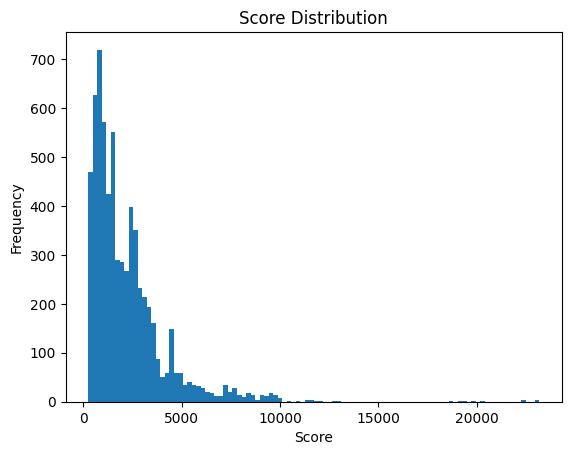

In [ ]:
plt.hist(best_alignments['score'], bins=100)
# plt.xlim(0, 2000)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Score Distribution')
plt.show()

# Map Secondary Structure

In [ ]:
def map_secondary_structure(row):
    aligned_target_seqs = row['alignments'][0]
    aligned_query_seqs = row['alignments'][1]
    ss_seq = row['pdb_secondary_structure']

    # Create boolean arrays indicating positions of gaps and residues
    query_gaps = np.array(list(aligned_query_seqs)) == '-'
    query_residues = ~query_gaps

    # Extract secondary structure elements for residues
    aligned_ss_residues = np.array(list(ss_seq))[np.cumsum(query_residues) - 1]

    # Create an array with gaps and ss
    aligned_ss = np.where(query_gaps, '-', aligned_ss_residues)

    # Keep only ss for target positions without gaps
    target_gaps = np.array(list(aligned_target_seqs)) == '-'
    target_ss = np.where(target_gaps, '-', aligned_ss)
    target_ss = ''.join(target_ss)

    # Remove all positions from target_ss that have '-' in aligned_target_seqs
    target_ss = ''.join([target_ss[i] for i in range(len(target_ss)) if aligned_target_seqs[i] != '-'])

    if len(target_ss) != len(row['ensembl_amino_acid_seq'][:-1]):
        print(f"Length mismatch: {len(target_ss)} vs {len(row['ensembl_amino_acid_seq'][:-1])}")

    return target_ss

best_alignments['target_secondary_structure'] = best_alignments.swifter.apply(map_secondary_structure, axis=1)

Pandas Apply: 100%|██████████| 7235/7235 [00:05<00:00, 1328.22it/s]


In [21]:
best_alignments.to_pickle('best_alignments.pkl')

# Graph Accuracy vs Secondary Structure

## Load Data

In [4]:
test_with_results = pd.read_pickle(os.path.join(data_path, '2_test_with_bart30.pkl'))
test_with_results['length (aa)'] = test_with_results['length (aa)'].astype(int)

best_alignments = pd.read_pickle('best_alignments.pkl')

test_with_results = test_with_results.merge(best_alignments[['ensembl_transcript_id', 'target_secondary_structure']], left_on='query_transcript', right_on='ensembl_transcript_id', how='left')

In [6]:
test_with_results['target_secondary_structure'].isna().sum()

np.int64(9296)

## Transcripts w./o. secondary structure

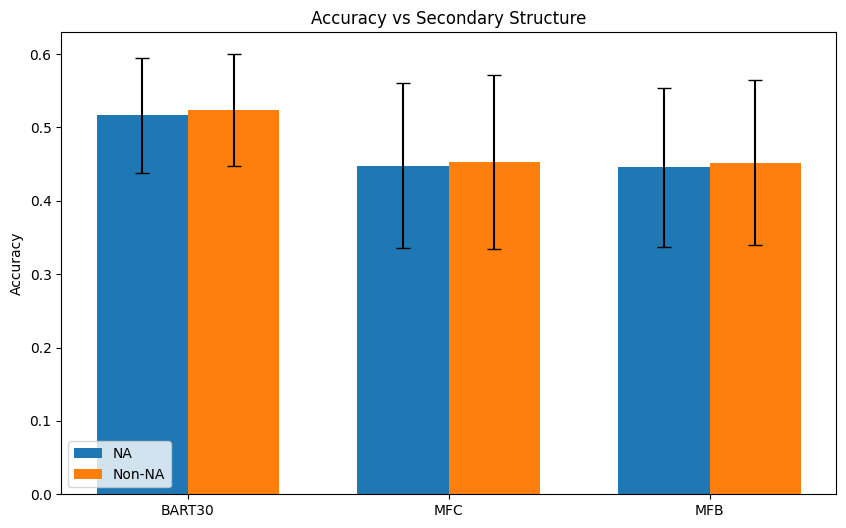

In [7]:
na_rows = test_with_results.loc[test_with_results['target_secondary_structure'].isna()]
non_na_rows = test_with_results.loc[~test_with_results['target_secondary_structure'].isna()]

bart_30_na = na_rows['bart30_accuracy']
mfc_na = na_rows['mfc_accuracy']
mfb_na = na_rows['mfb_accuracy']

bart_30_non_na = non_na_rows['bart30_accuracy']
mfc_non_na = non_na_rows['mfc_accuracy']
mfb_non_na = non_na_rows['mfb_accuracy']

# Model names
models = ['BART30', 'MFC', 'MFB']

# Accuracy values for NA and Non-NA
na_means = [bart_30_na.mean(), mfc_na.mean(), mfb_na.mean()]
non_na_means = [bart_30_non_na.mean(), mfc_non_na.mean(), mfb_non_na.mean()]

na_stds = [bart_30_na.std(), mfc_na.std(), mfb_na.std()]
non_na_stds = [bart_30_non_na.std(), mfc_non_na.std(), mfb_non_na.std()]

# Width of each bar
bar_width = 0.35

# Positions of the bars on the x-axis
x_pos = np.arange(len(models))

# Create the bar plot
fig, ax = plt.subplots(figsize=(10, 6))

# Bars for NA
rects1 = ax.bar(x_pos - bar_width/2, na_means, bar_width, yerr=na_stds, capsize=5, label='NA')

# Bars for Non-NA
rects2 = ax.bar(x_pos + bar_width/2, non_na_means, bar_width, yerr=non_na_stds, capsize=5, label='Non-NA')

# Set labels, title, and legend
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Secondary Structure')
ax.set_xticks(x_pos)
ax.set_xticklabels(models)
ax.legend()

# Display the plot
plt.show()

## Accuracy by Secondary Structure

In [8]:
# test_with_results['target_secondary_structure'] = test_with_results.apply(lambda x: '-' * int(x['length (aa)']) if isinstance(x['target_secondary_structure'], float) else x['target_secondary_structure'], axis=1)
test_with_results_nona = test_with_results.dropna(subset=['target_secondary_structure'], inplace=False)

# Initialize dictionaries to store the counts of correct predictions and total counts for each amino acid
ss_accuracy_counts = {
    'MFC': {},
    'MFB': {},
    'BART30': {},
    'BART30_Ablation': {}
}

# Iterate through each row in the DataFrame
for index, row in test_with_results_nona.iterrows():
    ground_truth_codons = row['seq'][:-3]
    secondary_structure = row['target_secondary_structure']

    for model in ['MFC', 'MFB', 'BART30_Ablation', 'BART30']:
        predicted_codons = row[f'{model.lower()}_prediction']

        for i in range(0, len(ground_truth_codons), 3):
            ground_truth_codon = ground_truth_codons[i:i+3]
            predicted_codon = predicted_codons[i:i+3]
            ss = secondary_structure[i//3]

            if ss not in ss_accuracy_counts[model]:
                ss_accuracy_counts[model][ss] = {'correct': 0, 'total': 0}

            if ground_truth_codon == predicted_codon:
                ss_accuracy_counts[model][ss]['correct'] += 1
            ss_accuracy_counts[model][ss]['total'] += 1

# Calculate the accuracy for each amino acid for each model
ss_accuracies = {
    'MFC': {},
    'MFB': {},
    'BART30': {},
    'BART30_Ablation': {}
}

for model in ['MFC', 'MFB', 'BART30_Ablation', 'BART30']:
    for ss, counts in ss_accuracy_counts[model].items():
        ss_accuracies[model][ss] = counts['correct'] / counts['total']

# Convert the results to a DataFrame for better visualization
ss_accuracies_df = pd.DataFrame(ss_accuracies)
print(ss_accuracies_df)

        MFC       MFB    BART30  BART30_Ablation
C  0.442035  0.438971  0.524640         0.520940
H  0.468836  0.468020  0.537055         0.533611
E  0.483950  0.481766  0.549693         0.548780
-  0.436419  0.437648  0.511582         0.507376


C:\Users\wsega\AppData\Local\Temp\ipykernel_11204\3787930965.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_text)


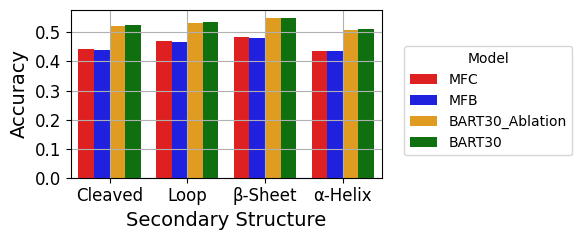

In [10]:
# Melt the DataFrame to long format for Seaborn
ss_accuracies_df_melt = pd.melt(ss_accuracies_df.reset_index(), id_vars=['index'], value_vars=['MFC', 'MFB', 'BART30', 'BART30_Ablation'], var_name='Model', value_name='Accuracy')

# Create the barplot
colors = ['red', 'blue', 'orange', 'green']
models = ['MFC', 'MFB', 'BART30_Ablation', 'BART30']
sns.set_palette(colors)
ss_accuracies_df_melt['Model'] = pd.Categorical(ss_accuracies_df_melt['Model'], categories=models, ordered=True)
ss_accuracies_df_melt['index'] = pd.Categorical(ss_accuracies_df_melt['index'], categories=ss_accuracies_df.index, ordered=True)
ss_accuracies_df_melt = ss_accuracies_df_melt.sort_values(by=['Model', 'index'])

plt.figure(figsize=(6, 2.5))
x_text = ['Cleaved', 'Loop', 'β-Sheet', 'α-Helix']
ax = sns.barplot(x='index', y='Accuracy', hue='Model', data=ss_accuracies_df_melt)
ax.set_xticklabels(x_text)
plt.xlabel('Secondary Structure', fontsize=14)
plt.xticks(fontsize=12)
plt.ylabel('Accuracy', fontsize=14)
plt.yticks(fontsize=12)
# plt.title('Accuracy by Secondary Structure and Model')

# Place the legend to the right of the plot
plt.legend(title='Model', bbox_to_anchor=(1.05, 0.825), loc='upper left')

plt.tight_layout()
plt.grid(True)

# save as svg format
plt.savefig('model_accuracies_by_secondary_structure.svg', format='svg', bbox_inches='tight')

plt.show()

C:\Users\wsega\AppData\Local\Temp\ipykernel_11204\1512507361.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_text)


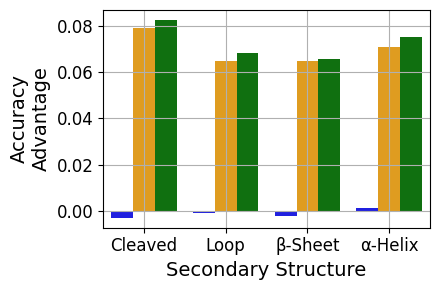

In [12]:
mfc_advantages = ss_accuracies_df[['MFB', 'BART30_Ablation', 'BART30']].to_numpy() - ss_accuracies_df['MFC'].to_numpy()[:, np.newaxis]
# Flatten the column index of mfc_advantages_df
mfc_advantages_df = pd.DataFrame(mfc_advantages, columns=['MFB', 'BART30_Ablation', 'BART30'], index=['-', 'C', 'E', 'H'])

# Melt the DataFrame to long format for Seaborn
mfc_advantages_df_melt = pd.melt(mfc_advantages_df.reset_index(), id_vars=['index'], value_vars=['MFB', 'BART30', 'BART30_Ablation'], var_name='Model', value_name='Accuracy')
mfc_advantages_df_melt.rename(columns={'index': 'Secondary Structure'}, inplace=True)

# Create the barplot
colors = ['blue', 'orange', 'green']
sns.set_palette(colors)
mfc_advantages_df_melt['Model'] = pd.Categorical(mfc_advantages_df_melt['Model'], categories=['MFB', 'BART30_Ablation', 'BART30'], ordered=True)
mfc_advantages_df_melt['Secondary Structure'] = pd.Categorical(mfc_advantages_df_melt['Secondary Structure'], categories=['-', 'C', 'E', 'H'], ordered=True)
mfc_advantages_df_melt = mfc_advantages_df_melt.sort_values(by=['Model', 'Secondary Structure'])

plt.figure(figsize=(4.5, 3))
x_text = ['Cleaved', 'Loop', 'β-Sheet', 'α-Helix']
ax = sns.barplot(x='Secondary Structure', y='Accuracy', hue='Model', data=mfc_advantages_df_melt)
ax.set_xticklabels(x_text)
plt.xlabel('Secondary Structure', fontsize=14)
plt.xticks(fontsize=12)
plt.ylabel('Accuracy\nAdvantage', fontsize=14)
plt.yticks(fontsize=12)
# plt.title('Accuracy by Secondary Structure and Model', fontsize=14)

# Place the legend below the plot
# ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=3)

# remove legend
ax.legend_.remove()

plt.tight_layout()
plt.grid(True)

# Save as SVG format
plt.savefig('mfc_advantages_by_secondary_structure.svg', format='svg', bbox_inches='tight')

plt.show()


## Amino Acid Accuracy vs. Secondary Structure Distribution

**Secondary Structure Distribution per Residue**

In [13]:
test_with_results_nona = test_with_results.dropna(subset=['target_secondary_structure'], inplace=False)

# Initialize a dictionary to store counts of secondary structure types for each amino acid
amino_acid_ss_counts = {}

# Iterate through each row in the DataFrame
for index, row in test_with_results_nona.iterrows():
    amino_acid_seq = row['amino_acid_seq'][:-1]  # Remove the stop codon
    secondary_structure = row['target_secondary_structure']

    # assert len(amino_acid_seq) == len(secondary_structure), f"Length mismatch: {len(amino_acid_seq)} vs {len(secondary_structure)}"

    for aa, ss in zip(amino_acid_seq, secondary_structure):
        if aa not in amino_acid_ss_counts:
            amino_acid_ss_counts[aa] = {'-': 0, 'C': 0, 'E': 0, 'H': 0}
        amino_acid_ss_counts[aa][ss] += 1

# Calculate percentages for each secondary structure type
amino_acid_ss_percentages = {}
for aa, counts in amino_acid_ss_counts.items():
    total = sum(counts.values())
    amino_acid_ss_percentages[aa] = {ss: (count / total) for ss, count in counts.items()}

# Convert the results to a DataFrame for better visualization
amino_acid_ss_df = pd.DataFrame(amino_acid_ss_percentages).T
amino_acid_ss_df.columns = ['Cleaved (-)', 'Loop (C)', 'β-Sheet (E)', 'α-Helix (H)']

# Save to pickle
amino_acid_ss_df.to_pickle('amino_acid_ss_df.pkl')

print(amino_acid_ss_df)


   Cleaved (-)  Loop (C)  β-Sheet (E)  α-Helix (H)
M     0.485622  0.139019     0.087921     0.287438
Q     0.531889  0.151818     0.058940     0.257353
R     0.516538  0.173856     0.071220     0.238386
S     0.594755  0.172513     0.054903     0.177828
P     0.612808  0.261502     0.025346     0.100343
L     0.446410  0.131082     0.103986     0.318521
E     0.525914  0.161999     0.053503     0.258585
K     0.481904  0.193563     0.070912     0.253622
A     0.520578  0.134000     0.063874     0.281548
V     0.444032  0.144303     0.180769     0.230896
F     0.391093  0.173171     0.143014     0.292723
W     0.385806  0.177038     0.136521     0.300635
T     0.512130  0.182484     0.093714     0.211672
I     0.382741  0.146305     0.174545     0.296409
G     0.529478  0.270191     0.051909     0.148422
Y     0.396037  0.180388     0.147693     0.275882
D     0.493909  0.243926     0.045449     0.216716
N     0.470929  0.258199     0.047609     0.223263
C     0.445773  0.204841     0.

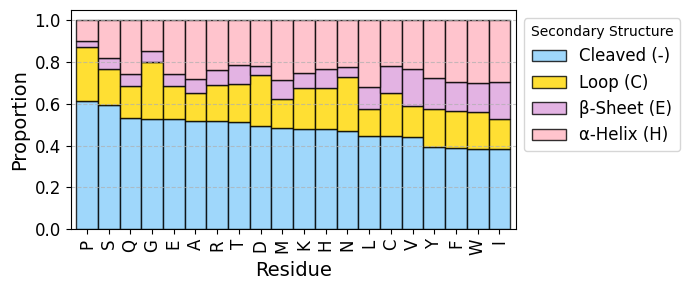

In [14]:
# Normalize the data so that each bar sums to 1.0
normalized_amino_acid_ss_df = amino_acid_ss_df.div(amino_acid_ss_df.sum(axis=1), axis=0)

# Define secondary structure columns
secondary_structure_columns = ['Cleaved (-)', 'Loop (C)', 'β-Sheet (E)', 'α-Helix (H)']

# Create a stacked bar plot

# color names
colors = ['lightskyblue', 'gold', 'plum', 'lightpink']

# Sort the DataFrame by 'Cleaved (-)' in descending order
sorted_amino_acid_ss_df = normalized_amino_acid_ss_df.sort_values(by='Cleaved (-)', ascending=False)

# Create a stacked bar plot with sorted data
ax = sorted_amino_acid_ss_df.plot(kind='bar', stacked=True, figsize=(7, 3), color=colors, alpha=0.8, width=1.0, edgecolor='black')

# Set labels and title
# ax.set_title('Stacked Bar Plot of Secondary Structure Distribution (Sorted by Cleaved)', fontsize=16)
ax.set_xlabel('Residue', fontsize=14)
ax.tick_params(axis='x', labelsize=12)
ax.set_ylabel('Proportion', fontsize=14)
ax.tick_params(axis='y', labelsize=12)
ax.legend(title='Secondary Structure', fontsize=12, loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()

# Save as SVG format
plt.savefig('amino_acid_ss_distribution.svg', format='svg', bbox_inches='tight')

plt.show()


**Residue Distribution per Secondary Structure**

In [47]:
test_with_results_nona = test_with_results.dropna(subset=['target_secondary_structure'], inplace=False)

# Initialize a dictionary to store counts of amino acids for each secondary structure type
ss_amino_acid_counts = {'-': {}, 'C': {}, 'E': {}, 'H': {}}

# Iterate through each row in the DataFrame
for index, row in test_with_results_nona.iterrows():
    amino_acid_seq = row['amino_acid_seq'][:-1]  # Remove the stop codon
    secondary_structure = row['target_secondary_structure']

    for aa, ss in zip(amino_acid_seq, secondary_structure):
        if ss not in ss_amino_acid_counts:
            ss_amino_acid_counts[ss] = {}
        if aa not in ss_amino_acid_counts[ss]:
            ss_amino_acid_counts[ss][aa] = 0
        ss_amino_acid_counts[ss][aa] += 1

# Calculate percentages for each amino acid in each secondary structure type
ss_amino_acid_percentages = {}
for ss, counts in ss_amino_acid_counts.items():
    total = sum(counts.values())
    ss_amino_acid_percentages[ss] = {aa: (count / total) for aa, count in counts.items()}

# Convert the results to a DataFrame for better visualization
ss_amino_acid_df = pd.DataFrame(ss_amino_acid_percentages).fillna(0)
ss_amino_acid_df.columns = ['Cleaved (-)', 'Loop (C)', 'β-Sheet (E)', 'α-Helix (H)']

# Save to pickle
ss_amino_acid_df.to_pickle('ss_amino_acid_df.pkl')

print(ss_amino_acid_df)


   Cleaved (-)  Loop (C)  β-Sheet (E)  α-Helix (H)
E     0.077181  0.064639     0.045819     0.079347
K     0.059450  0.064924     0.051050     0.065421
A     0.071454  0.050008     0.051161     0.080803
Q     0.050391  0.039106     0.032585     0.050980
N     0.035537  0.052975     0.020965     0.035227
R     0.059330  0.054295     0.047737     0.057252
T     0.053922  0.052240     0.057580     0.046600
S     0.096098  0.075786     0.051766     0.060077
G     0.068641  0.095235     0.039269     0.040232
D     0.050735  0.068126     0.027243     0.046546
L     0.086739  0.069250     0.117906     0.129406
F     0.028378  0.034163     0.060555     0.044411
P     0.073545  0.085329     0.017751     0.025180
M     0.022081  0.017186     0.023328     0.027327
C     0.018048  0.022548     0.031066     0.018445
I     0.036270  0.037696     0.096522     0.058731
H     0.024029  0.027052     0.025698     0.024625
V     0.055912  0.049404     0.132828     0.060792
W     0.009310  0.011615     0.

**Secondary Structure By number of codons**

In [48]:
# Dictionary mapping amino acids to the number of codons
# Calculate the number of codons for each amino acid
from Bio.Data import CodonTable

# Get the standard codon table from Biopython
aa_to_codons = {}
for codon, amino_acid in CodonTable.unambiguous_dna_by_id[1].forward_table.items():
    if amino_acid not in aa_to_codons:
        aa_to_codons[amino_acid] = []
    aa_to_codons[amino_acid].append(codon)

amino_acid_to_codons = {aa: len(codons) for aa, codons in codon_table.items()}

# Add the 'num_codons' column to the DataFrame
ss_amino_acid_df['num_codons'] = ss_amino_acid_df.index.map(amino_acid_to_codons)

print(ss_amino_acid_df)

   Cleaved (-)  Loop (C)  β-Sheet (E)  α-Helix (H)  num_codons
E     0.077181  0.064639     0.045819     0.079347           2
K     0.059450  0.064924     0.051050     0.065421           2
A     0.071454  0.050008     0.051161     0.080803           4
Q     0.050391  0.039106     0.032585     0.050980           2
N     0.035537  0.052975     0.020965     0.035227           2
R     0.059330  0.054295     0.047737     0.057252           6
T     0.053922  0.052240     0.057580     0.046600           4
S     0.096098  0.075786     0.051766     0.060077           6
G     0.068641  0.095235     0.039269     0.040232           4
D     0.050735  0.068126     0.027243     0.046546           2
L     0.086739  0.069250     0.117906     0.129406           6
F     0.028378  0.034163     0.060555     0.044411           2
P     0.073545  0.085329     0.017751     0.025180           4
M     0.022081  0.017186     0.023328     0.027327           1
C     0.018048  0.022548     0.031066     0.018445     

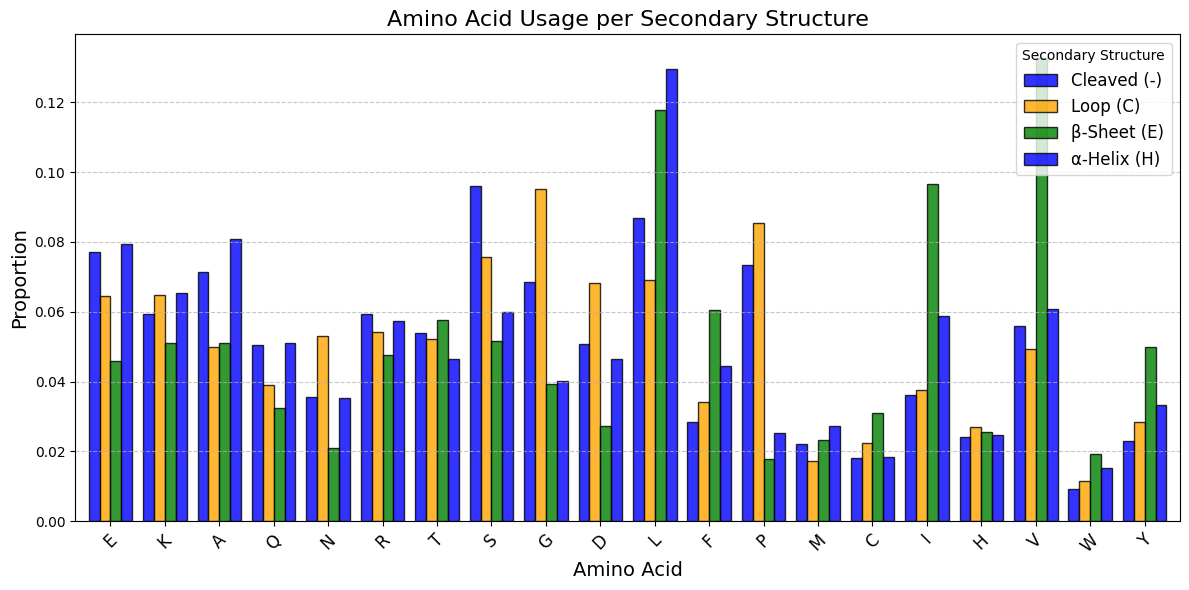

In [66]:
# Create a bar plot for amino acid usage per secondary structure
secondary_structure_columns = ss_amino_acid_df.columns[:-1]  # Exclude 'num_codons' column
ss_amino_acid_df[secondary_structure_columns].plot(kind='bar', figsize=(12, 6), width=0.8, alpha=0.8, edgecolor='black')

# Set labels and title
plt.xlabel('Amino Acid', fontsize=14)
plt.ylabel('Proportion', fontsize=14)
plt.title('Amino Acid Usage per Secondary Structure', fontsize=16)
plt.xticks(ticks=range(len(ss_amino_acid_df.index)), labels=ss_amino_acid_df.index, rotation=45, fontsize=12)
plt.legend(title='Secondary Structure', fontsize=12, loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

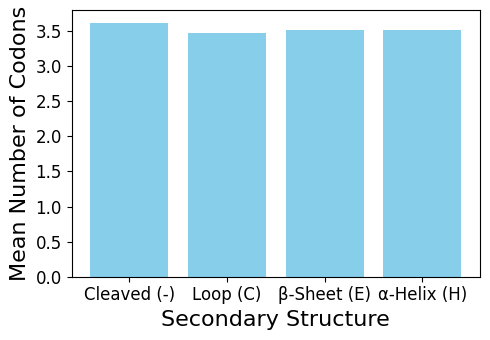

In [65]:
mean_num_codons_per_ss = (ss_amino_acid_df['num_codons'].values[:, np.newaxis] * ss_amino_acid_df[['Cleaved (-)', 'Loop (C)', 'β-Sheet (E)', 'α-Helix (H)']].values).sum(axis=0)

# Bar plot of the mean number of codons per secondary structure
plt.figure(figsize=(5, 3.5))

plt.bar(ss_amino_acid_df.columns[:-1], mean_num_codons_per_ss, color='skyblue')

# plt.title('Mean Number of Codons per Secondary Structure')
plt.xlabel('Secondary Structure', fontsize=16)
plt.ylabel('Mean Number of Codons', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.savefig('mean_num_codons_per_ss.svg', format='svg', bbox_inches='tight')

plt.show()

**Accuracy per residue**

In [15]:
# Initialize dictionaries to store the counts of correct predictions and total counts for each amino acid
amino_acid_accuracy_counts = {
    'MFC': {},
    'MFB': {},
    'BART30': {},
    'BART30_Ablation': {}
}

# Iterate through each row in the DataFrame
for index, row in test_with_results.iterrows():
    ground_truth_codons = row['seq']
    amino_acids = row['amino_acid_seq']
    
    for model in ['MFC', 'MFB', 'BART30_Ablation', 'BART30']:
        predicted_codons = row[f'{model.lower()}_prediction']
        
        for i in range(0, len(ground_truth_codons[:-3]), 3):  # remove stop codon
            ground_truth_codon = ground_truth_codons[i:i+3]
            predicted_codon = predicted_codons[i:i+3]
            amino_acid = amino_acids[i//3]
            
            if amino_acid not in amino_acid_accuracy_counts[model]:
                amino_acid_accuracy_counts[model][amino_acid] = {'correct': 0, 'total': 0}
            
            if ground_truth_codon == predicted_codon:
                amino_acid_accuracy_counts[model][amino_acid]['correct'] += 1
            amino_acid_accuracy_counts[model][amino_acid]['total'] += 1

# Calculate the accuracy for each amino acid for each model
amino_acid_accuracies = {
    'MFC': {},
    'MFB': {},
    'BART30': {},
    'BART30_Ablation': {}
}

for model in ['MFC', 'MFB', 'BART30_Ablation', 'BART30']:
    for amino_acid, counts in amino_acid_accuracy_counts[model].items():
        amino_acid_accuracies[model][amino_acid] = counts['correct'] / counts['total']

# Convert the results to a DataFrame for better visualization
amino_acid_accuracies_df = pd.DataFrame(amino_acid_accuracies)
print(amino_acid_accuracies_df)

        MFC       MFB    BART30  BART30_Ablation
M  1.000000  1.000000  1.000000         1.000000
S  0.234749  0.236427  0.291059         0.288891
R  0.227589  0.228122  0.303679         0.294752
V  0.450665  0.450665  0.459688         0.457931
Q  0.726355  0.726355  0.728214         0.728060
T  0.329327  0.326701  0.430442         0.427798
N  0.511197  0.511012  0.670252         0.666271
Y  0.536597  0.535599  0.676213         0.674436
G  0.318466  0.315447  0.399128         0.393309
L  0.375840  0.375840  0.389730         0.387130
A  0.381112  0.380780  0.464243         0.461757
F  0.514055  0.512317  0.685827         0.679316
K  0.550925  0.547160  0.598831         0.586587
E  0.557676  0.554448  0.614787         0.604273
P  0.306977  0.314247  0.411096         0.409499
C  0.515230  0.511068  0.706244         0.700428
I  0.439759  0.435127  0.545723         0.542155
D  0.510927  0.511146  0.685495         0.682233
H  0.548487  0.543092  0.657529         0.650085
W  1.000000  1.00000

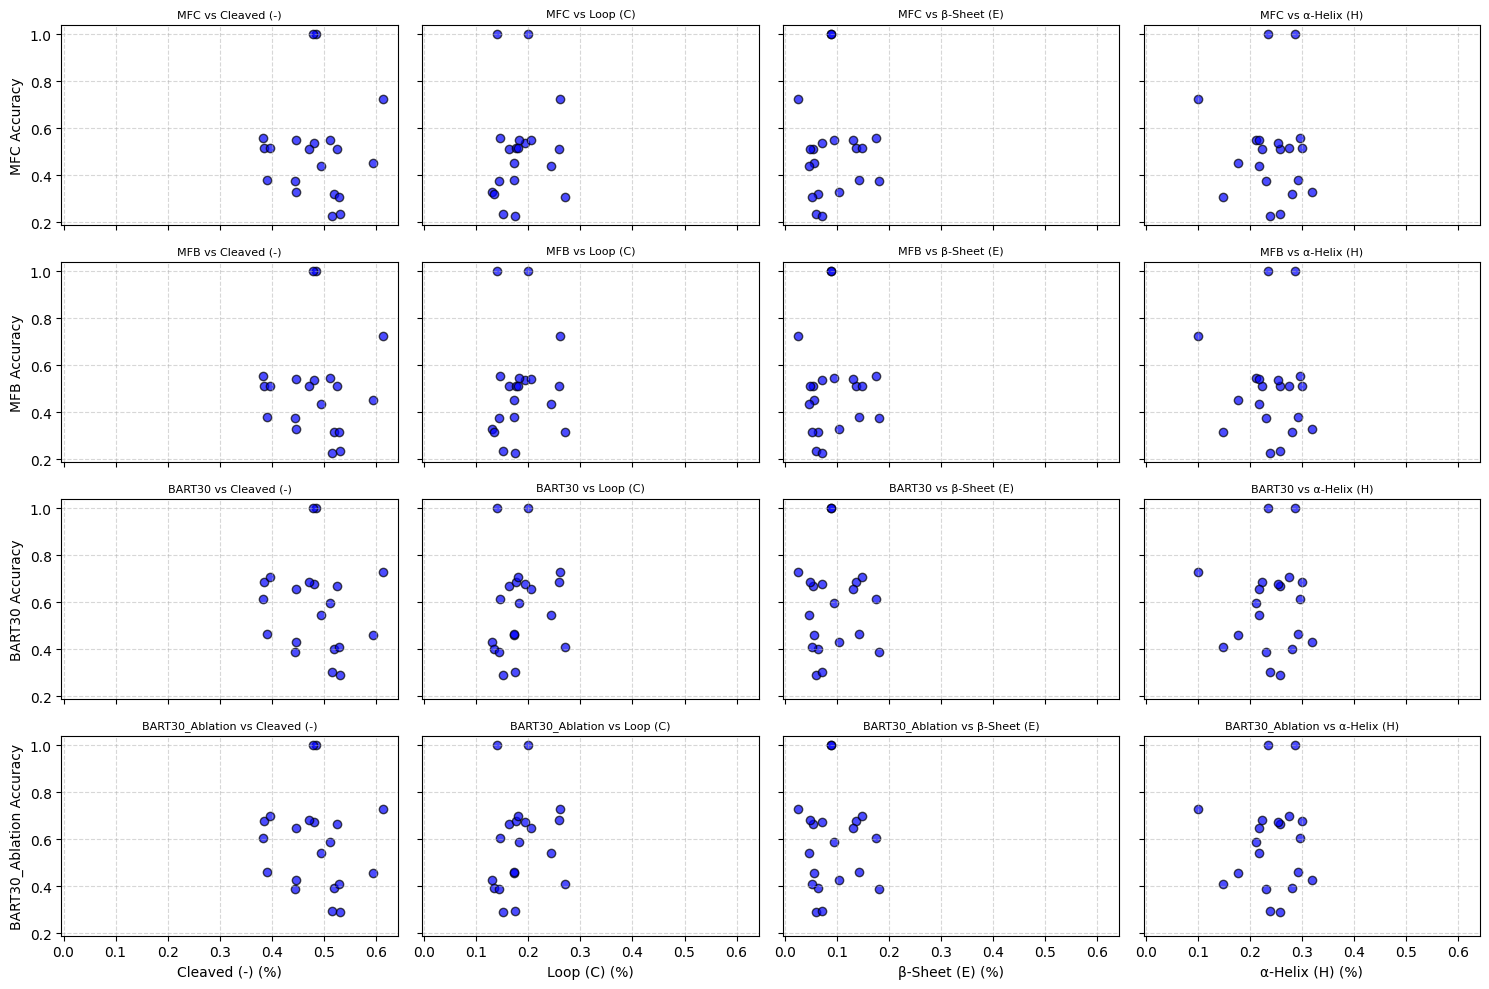

In [16]:
# Define models and secondary structure columns
models = amino_acid_accuracies_df.columns
secondary_structures = amino_acid_ss_df.columns

# Create subplots
fig, axes = plt.subplots(len(models), len(secondary_structures), figsize=(15, 10), sharex=True, sharey=True)

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate through each model and secondary structure
for i, model in enumerate(models):
    for j, ss in enumerate(secondary_structures):
        ax = axes[i * len(secondary_structures) + j]
        
        # Scatter plot of amino acid accuracy vs percentage of secondary structure
        x = amino_acid_ss_df[ss]
        y = amino_acid_accuracies_df[model]
        ax.scatter(x, y, alpha=0.7, edgecolor='k')
        
        # Set labels and title
        if i == len(models) - 1:
            ax.set_xlabel(f'{ss} (%)', fontsize=10)
        if j == 0:
            ax.set_ylabel(f'{model} Accuracy', fontsize=10)
        ax.set_title(f'{model} vs {ss}', fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.5)

# Adjust layout
plt.tight_layout()
plt.show()

## Codon Accuracy vs. Secondary Structure Distribution

**Secondary Structure Distribution per Residue**

In [17]:
# split 'ATGCGATGACTGACTGA' into codons
def split_into_codons(seq):
    return [seq[i:i+3] for i in range(0, len(seq), 3)]

In [18]:
test_with_results_nona = test_with_results.dropna(subset=['target_secondary_structure'], inplace=False)

# Initialize a dictionary to store counts of secondary structure types for each codon
codon_ss_counts = {}

# Iterate through each row in the DataFrame
for index, row in test_with_results_nona.iterrows():
    seq = row['seq']
    codon_seq = [seq[i:i+3] for i in range(0, len(seq), 3)][:-1]  # split into codons and remove the stop codon
    secondary_structure = row['target_secondary_structure']

    # assert len(codon_seq // 3) == len(secondary_structure), f"Length mismatch: {len(codon_seq // 3)} vs {len(secondary_structure)}"

    for c, ss in zip(codon_seq, secondary_structure):
        if c not in codon_ss_counts:
            codon_ss_counts[c] = {'-': 0, 'C': 0, 'E': 0, 'H': 0}
        codon_ss_counts[c][ss] += 1

# Calculate percentages for each secondary structure type
codon_ss_percentages = {}
for c, counts in codon_ss_counts.items():
    total = sum(counts.values())
    codon_ss_percentages[c] = {ss: (count / total) for ss, count in counts.items()}

# Convert the results to a DataFrame for better visualization
codon_ss_df = pd.DataFrame(codon_ss_percentages).T
codon_ss_df.columns = ['Cleaved (-)', 'Loop (C)', 'β-Sheet (E)', 'α-Helix (H)']

# Save to pickle
codon_ss_df.to_pickle('codon_ss_df.pkl')

print(codon_ss_df)

     Cleaved (-)  Loop (C)  β-Sheet (E)  α-Helix (H)
ATG     0.485622  0.139019     0.087921     0.287438
CAG     0.530594  0.150081     0.060178     0.259146
AGG     0.545547  0.167862     0.063078     0.223512
TCG     0.607653  0.173147     0.056850     0.162351
CCT     0.601060  0.268943     0.026542     0.103455
..           ...       ...          ...          ...
ACT     0.520233  0.188700     0.085934     0.205133
CGT     0.484758  0.193176     0.079581     0.242486
GGT     0.531073  0.252104     0.050977     0.165847
CCC     0.611956  0.257947     0.031679     0.098418
ACG     0.517763  0.170229     0.106674     0.205334

[61 rows x 4 columns]


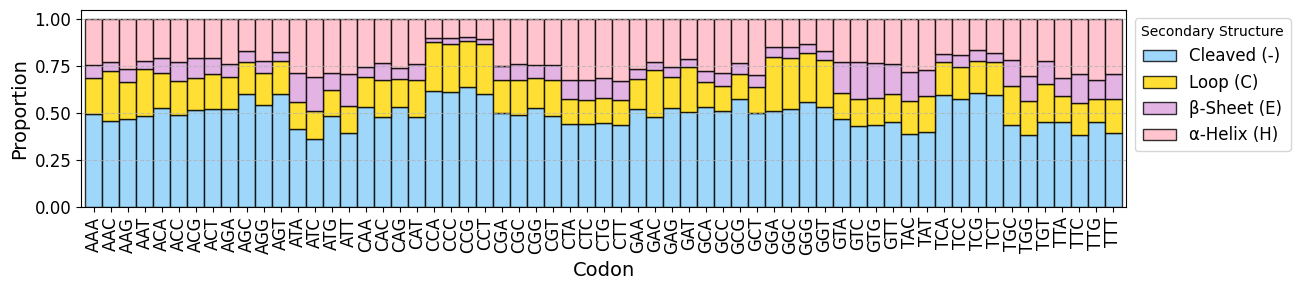

In [19]:
# Normalize the data so that each bar sums to 1.0
normalized_codon_ss_df = codon_ss_df.div(codon_ss_df.sum(axis=1), axis=0)

# Define secondary structure columns
secondary_structure_columns = ['Cleaved (-)', 'Loop (C)', 'β-Sheet (E)', 'α-Helix (H)']

# Create a stacked bar plot

# color names
colors = ['lightskyblue', 'gold', 'plum', 'lightpink']

# Sort codons alphabetically
sorted_codon_ss_df = normalized_codon_ss_df.sort_index()

# Create a stacked bar plot with sorted data
ax = sorted_codon_ss_df.plot(kind='bar', stacked=True, figsize=(13, 3), color=colors, alpha=0.8, width=1.0, edgecolor='black')

# Set labels and title
# ax.set_title('Stacked Bar Plot of Secondary Structure Distribution (Sorted by Cleaved)', fontsize=16)
ax.set_xlabel('Codon', fontsize=14)
ax.tick_params(axis='x', labelsize=12)
ax.set_ylabel('Proportion', fontsize=14)
ax.tick_params(axis='y', labelsize=12)
ax.legend(title='Secondary Structure', fontsize=12, loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()

# Save as SVG format
plt.savefig('codon_ss_distribution.svg', format='svg', bbox_inches='tight')

plt.show()


**Accuracy per residue**

In [20]:
# Initialize dictionaries to store the counts of correct predictions and total counts for each codon
codon_accuracy_counts = {
    'MFC': {},
    'MFB': {},
    'BART30': {},
    'BART30_Ablation': {}
}

# Iterate through each row in the DataFrame
for index, row in test_with_results.iterrows():
    ground_truth_codons = row['seq']
    
    for model in ['MFC', 'MFB', 'BART30_Ablation', 'BART30']:
        predicted_codons = row[f'{model.lower()}_prediction']
        
        for i in range(0, len(ground_truth_codons[:-3]), 3):  # remove stop codon
            ground_truth_codon = ground_truth_codons[i:i+3]
            predicted_codon = predicted_codons[i:i+3]
            
            if ground_truth_codon not in codon_accuracy_counts[model]:
                codon_accuracy_counts[model][ground_truth_codon] = {'correct': 0, 'total': 0}
            
            if ground_truth_codon == predicted_codon:
                codon_accuracy_counts[model][ground_truth_codon]['correct'] += 1
            codon_accuracy_counts[model][ground_truth_codon]['total'] += 1

# Calculate the accuracy for each codon for each model
codon_accuracies = {
    'MFC': {},
    'MFB': {},
    'BART30': {},
    'BART30_Ablation': {}
}

for model in ['MFC', 'MFB', 'BART30_Ablation', 'BART30']:
    for codon, counts in codon_accuracy_counts[model].items():
        codon_accuracies[model][codon] = counts['correct'] / counts['total']

# Convert the results to a DataFrame for better visualization
codon_accuracies_df = pd.DataFrame(codon_accuracies)
print(codon_accuracies_df)

     MFC       MFB    BART30  BART30_Ablation
ATG  1.0  1.000000  1.000000         1.000000
AGC  1.0  0.891998  0.438696         0.404697
AGA  1.0  0.203455  0.538705         0.539918
GTG  1.0  1.000000  0.895160         0.939663
CAG  1.0  1.000000  0.983511         0.991246
..   ...       ...       ...              ...
TGT  0.0  0.056818  0.557518         0.513994
TAT  0.0  0.060066  0.516042         0.469378
CGG  0.0  0.369030  0.343946         0.328855
CGT  0.0  0.000000  0.001092         0.002549
CTA  0.0  0.000000  0.000000         0.000000

[61 rows x 4 columns]


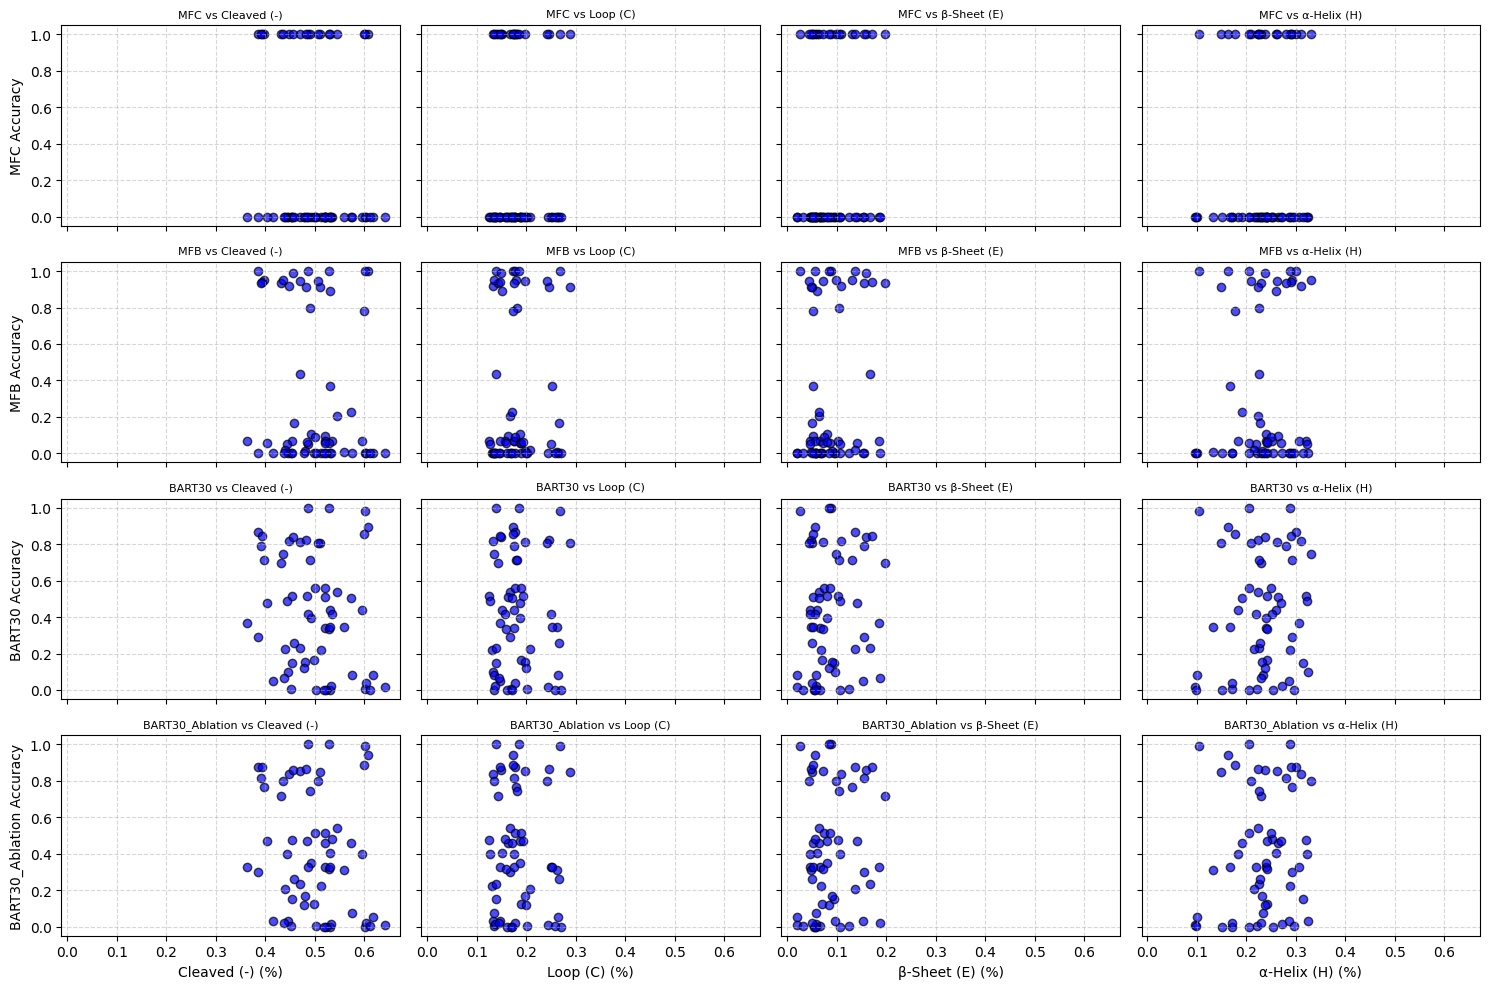

In [21]:
# Define models and secondary structure columns
models = codon_accuracies_df.columns
secondary_structures = codon_ss_df.columns

# Create subplots
fig, axes = plt.subplots(len(models), len(secondary_structures), figsize=(15, 10), sharex=True, sharey=True)

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate through each model and secondary structure
for i, model in enumerate(models):
    for j, ss in enumerate(secondary_structures):
        ax = axes[i * len(secondary_structures) + j]
        
        # Scatter plot of codon accuracy vs percentage of secondary structure
        x = codon_ss_df[ss]
        y = codon_accuracies_df[model]
        ax.scatter(x, y, alpha=0.7, edgecolor='k')
        
        # Set labels and title
        if i == len(models) - 1:
            ax.set_xlabel(f'{ss} (%)', fontsize=10)
        if j == 0:
            ax.set_ylabel(f'{model} Accuracy', fontsize=10)
        ax.set_title(f'{model} vs {ss}', fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.5)

# Adjust layout
plt.tight_layout()
plt.show()